# PairPulse reproduction notebook

This notebook reproduces the single-pulse validation and separated double-pulse spectrum in the manuscript. Install PairPulse with its `plots` dependencies into the selected notebook kernel first. The notebook imports the installed package and can run outside the source directory. All calculations use natural units with `m=q=1`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import pairpulse
from pairpulse import (PulseTrain, SauterPulse, integrated_density,
                       sauter_exact_occupation, solve_dirac_mode,
                       solve_qke_mode)
plt.rcParams.update({'axes.labelsize':20,'xtick.labelsize':20,
                     'ytick.labelsize':20,'legend.fontsize':20})
print('Python:', sys.version)
print('Installed package:', pairpulse.__file__)


Python: 3.12.15 (main, Oct  1 2026, 02:35:59) [GCC 13.3.0]
Installed package: /opt/hostedtoolcache/Python/3.12.15/x64/lib/python3.12/site-packages/pairpulse/__init__.py


## Exact single-pulse benchmark

The pulse is `E0=0.3`, `tau=2`. The exact Sauter result is compared with direct Dirac-mode evolution and the quantum-kinetic equations.

In [2]:
single = SauterPulse(amplitude=0.3, duration=2.0)
p0 = 0.0
exact0 = sauter_exact_occupation(p0, single)
dirac0 = solve_dirac_mode(p0, single)
qke0 = solve_qke_mode(p0, single)
print(f'exact      = {exact0:.15g}')
print(f'Dirac      = {dirac0.occupation:.15g}; norm error = {dirac0.diagnostic:.3e}')
print(f'QKE        = {qke0.occupation:.15g}; invariant error = {qke0.diagnostic:.3e}')
print(f'|Dirac-exact| = {abs(dirac0.occupation-exact0):.3e}')
print(f'|QKE-exact|   = {abs(qke0.occupation-exact0):.3e}')

exact      = 0.000811991615992789
Dirac      = 0.000811991615244663; norm error = 5.006e-13
QKE        = 0.00081199161523844; invariant error = 9.064e-13
|Dirac-exact| = 7.481e-13
|QKE-exact|   = 7.543e-13


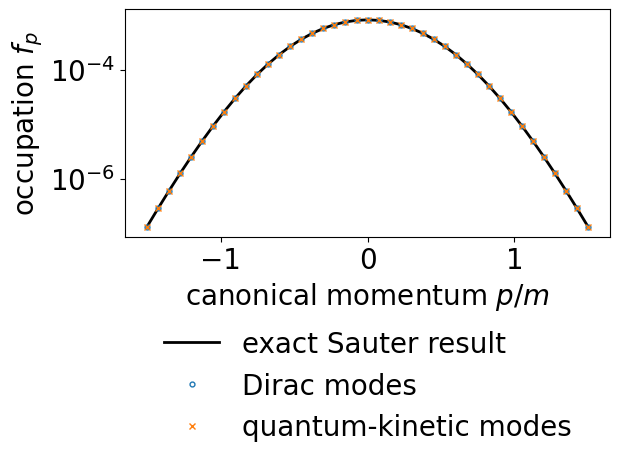

maximum absolute errors: 7.48126061968224e-13 7.543497076989425e-13


In [3]:
p = np.linspace(-1.5, 1.5, 41)
f_dirac = np.array([solve_dirac_mode(float(x), single).occupation for x in p])
f_qke = np.array([solve_qke_mode(float(x), single).occupation for x in p])
f_exact = np.array([sauter_exact_occupation(float(x), single) for x in p])
plt.figure(figsize=(6.3, 5.3))
plt.semilogy(p, f_exact, color='black', lw=2, label='exact Sauter result')
plt.semilogy(p, f_dirac, 'o', ms=3.5, mfc='none', label='Dirac modes')
plt.semilogy(p, f_qke, 'x', ms=4.2, label='quantum-kinetic modes')
plt.xlabel(r'canonical momentum $p/m$'); plt.ylabel(r'occupation $f_p$')
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.30)); plt.tight_layout(); plt.show()
print('maximum absolute errors:', np.max(np.abs(f_dirac-f_exact)), np.max(np.abs(f_qke-f_exact)))

## Separated pulse train

The following calculation has no analytic benchmark in the package. Agreement between the two formulations is the numerical cross-check; it does not imply a new physical mechanism.

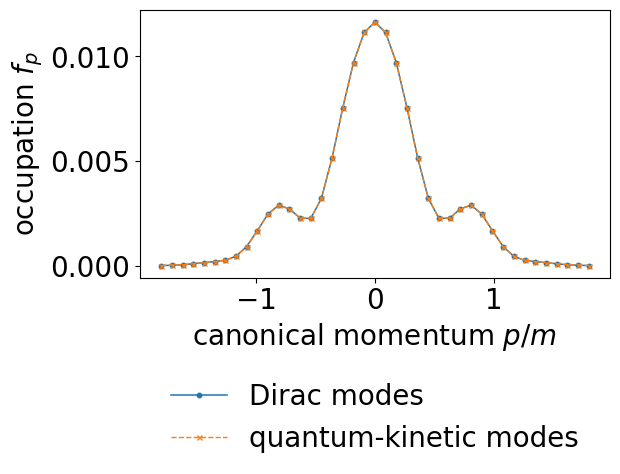

finite-window densities: 0.0016919881473807733 0.001691988147392702


In [4]:
double = PulseTrain((SauterPulse(0.30, 1.1, -3.5),
                     SauterPulse(0.30, 1.1,  3.5)))
pd = np.linspace(-1.8, 1.8, 41)
fd = np.array([solve_dirac_mode(float(x), double).occupation for x in pd])
fk = np.array([solve_qke_mode(float(x), double).occupation for x in pd])
plt.figure(figsize=(6.3, 5.3))
plt.plot(pd, fd, 'o-', ms=3.2, lw=1.1, label='Dirac modes')
plt.plot(pd, fk, 'x--', ms=3.6, lw=1.0, label='quantum-kinetic modes')
plt.xlabel(r'canonical momentum $p/m$'); plt.ylabel(r'occupation $f_p$')
plt.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.30)); plt.tight_layout(); plt.show()
print('finite-window densities:', integrated_density(pd, fd), integrated_density(pd, fk))

To recompute the spectra, tail scan and error map, run both commands from the project root, preserving the archived `results/` files:

```bash
python scripts/reproduce.py --output regenerated --points 41
python scripts/make_reproducibility_figures.py --output regenerated --points 41
```

To redraw all six publication figures from the archived data without new integrations:

```bash
python scripts/redraw_figures.py --data results --output redrawn
```

The notebook provides an interactive walkthrough. The shared plotting functions in the scripts define the publication artwork. Floating-point differences between environments are expected; byte-identical numerical output is not promised.